# Gram Type Classification

**- removes some NaN columns (where more than 50% are NaNs)**

**- different t hats - max value used**

We will build one single envelope trained on true-label score vectors:

- For a gram-neg phage: use its scores as-is (low score = strong evidence against gram postive thus gram-neg signal is good)
- For a gram-pos phage: use 1 − score for every dimension (the original scores measure gram-positive evidence)

Every training phage contributes exactly one point to the envelope — its score vector oriented toward its true host. The envelope learns what a true infector looks like, regardless of which gram type that is.

### At Testing
For each test phage we will create two candidate score vectors:
1. Scores as-is → hypothesis: this phage is gram-neg
2. 1 − scores  → hypothesis: this phage is gram-pos

We check both against the single envelope:
- Both inside  → prediction set = {gram-neg, gram-pos} (size 2, uncertain)
- Only as-is inside → prediction set = {gram-neg} (size 1)
- Only flipped inside → prediction set = {gram-pos} (size 1)
- Neither inside → prediction set = {} (size 0)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

### Loading the Data

In [4]:
SCORES_PATH = "../../Data/host_type_all_preds.csv"
METADATA_PATH = "../../Data/metadata.csv"

print("Loading scores...")
t0 = time.time()
scores_df = pd.read_csv(SCORES_PATH, index_col="proteinID")
print(f"  scores shape : {scores_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
print(f"  metadata shape : {meta_df.shape}  ({time.time()-t0:.1f}s)")

meta_df = meta_df[["accession", "host_type", "split"]]

Loading scores...
  scores shape : (1853074, 40)  (2.9s)
Loading metadata...
  metadata shape : (1853074, 8)  (3.3s)


#### Seeing how the data looks like

In [5]:
# scores file
print(scores_df.head())

                host_type_lysin  host_type_endolysin  host_type_val  \
proteinID                                                             
AB002632_00001              NaN                  NaN            NaN   
AB002632_00002              NaN                  NaN            NaN   
AB002632_00003              NaN                  NaN            NaN   
AB002632_00004              NaN                  NaN            NaN   
AB002632_00005              NaN                  NaN            NaN   

                host_type_capsid  host_type_baseplate  \
proteinID                                               
AB002632_00001               NaN                  NaN   
AB002632_00002               NaN                  NaN   
AB002632_00003          0.029791                  NaN   
AB002632_00004               NaN                  NaN   
AB002632_00005          0.008570                  NaN   

                host_type_tail_appendage  host_type_tail_sheath  \
proteinID                          

In [6]:
# metadata file
print(meta_df.head(10))

               accession host_type  split
proteinID                                
AB002632_00001  AB002632  gram-neg      0
AB002632_00002  AB002632  gram-neg      0
AB002632_00003  AB002632  gram-neg      0
AB002632_00004  AB002632  gram-neg      0
AB002632_00005  AB002632  gram-neg      0
AB002632_00006  AB002632  gram-neg      0
AB002632_00007  AB002632  gram-neg      0
AB002632_00008  AB002632  gram-neg      0
AB002632_00009  AB002632  gram-neg      0
AB002632_00010  AB002632  gram-neg      0


### Joining and Mean-Pooling to Phage Level
We join the two files by the "ProteinID" the Mean-Pool with respect to the phage (we average the scores for each function for one phage to get one score vector per phage instead of having one vector per protein)

In [7]:
combined = scores_df.join(meta_df, how="inner")
score_cols = [c for c in scores_df.columns if c.startswith("host_type_")]

t0 = time.time()
phage_scores = combined.groupby("accession")[score_cols].mean()
phage_meta = combined.groupby("accession")[["host_type", "split"]].first()
phage_df = phage_scores.join(phage_meta)

print(f"Phage-level shape: {phage_df.shape}  ({time.time()-t0:.1f}s)")
print("\nGram-type distribution:")
print(phage_df["host_type"].value_counts())
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())

Phage-level shape: (18474, 42)  (0.6s)

Gram-type distribution:
host_type
gram-neg    10735
gram-pos     7708
unknown        31
Name: count, dtype: int64

Split distribution:
split
0    4433
1    3173
2    3646
3    3588
4    3634
Name: count, dtype: int64


### Train / Test Split + Median Imputation
We impute all the NaNs with the median value of the column

In [8]:
# train_df = phage_df[phage_df["split"] != 0].copy()
# test_df = phage_df[phage_df["split"] == 0].copy()

# train_df = train_df[train_df["host_type"].isin(["gram-neg", "gram-pos"])]
# test_df = test_df [test_df ["host_type"].isin(["gram-neg", "gram-pos"])]

# print(f"Train phages : {len(train_df)}")
# print(f"Test  phages : {len(test_df)}")

In [9]:
split0_df = phage_df[phage_df["split"] == 0].copy()
split0_df = split0_df[split0_df["host_type"].isin(["gram-neg", "gram-pos"])]

# random 80/20 split within split 0
np.random.seed(42)
idx = np.random.permutation(len(split0_df))
cut = int(0.8 * len(split0_df))
train_df = split0_df.iloc[idx[:cut]]
test_df  = split0_df.iloc[idx[cut:]]

### NaN Column Filtering
We drop the columns wih >50% of the phages have NaNs
This is done because
- Columns with more than 50% missing data at the phage level provide very little information. Including them would mean that our evidence vector is mostly made of imputed/filler values rather than actual model predictions.
- In our methods the complexity increases significantly with the number of dimensions ($K$). 
- This reduction helps the conformal envelopes stay tighter and more "efficient," leading to smaller, more useful prediction sets.
- We use median imputation to fill remaining NaNs, imputing 90% of a column would artificially flatten that feature. 

In [10]:
# nan_rates = phage_df[score_cols].isna().mean().sort_values(ascending=False)
# NAN_THRESHOLD = 0.50
# valid_cols = nan_rates[nan_rates <= NAN_THRESHOLD].index.tolist()
# dropped = nan_rates[nan_rates  > NAN_THRESHOLD].index.tolist()
# K = len(valid_cols)
# print(f"Columns kept   : {K} / {len(score_cols)}")
# print(f"Columns dropped: {len(dropped)}")
# print(f"  Dropped: {dropped}")
# print(f"\nFinal K = {K}")

In [11]:
# NaN column filtering — computed on training data only
nan_rates = train_df[score_cols].isna().mean().sort_values(ascending=False)
NAN_THRESHOLD = 0.50
valid_cols = nan_rates[nan_rates <= NAN_THRESHOLD].index.tolist()
dropped = nan_rates[nan_rates > NAN_THRESHOLD].index.tolist()
K = len(valid_cols)
print(f"Columns kept   : {K} / {len(score_cols)}")
print(f"Columns dropped: {len(dropped)}")
print(f"  Dropped: {dropped}")
print(f"\nFinal K = {K}")

Columns kept   : 26 / 40
Columns dropped: 14
  Dropped: ['host_type_sir2', 'host_type_lysis_inhibitor', 'host_type_super_infection', 'host_type_toxin', 'host_type_ejection', 'host_type_transcriptional_activator', 'host_type_tail_sheath', 'host_type_replication_initiation', 'host_type_reductase', 'host_type_annealing', 'host_type_spanin', 'host_type_baseplate', 'host_type_nucleotide_metabolism', 'host_type_primase']

Final K = 26


#### Median imputation (from training set only)
(we replace all the NaNs by the median of the column so when we are plotting it doesnt force the point in or out of the envelope)

In [12]:
train_medians = train_df[valid_cols].median()
safe_impute_values = train_medians.copy()
safe_impute_values[safe_impute_values > 0.6] = 0.5

train_df[valid_cols] = train_df[valid_cols].fillna(safe_impute_values)
test_df [valid_cols] = test_df [valid_cols].fillna(safe_impute_values)
train_df[valid_cols] = train_df[valid_cols].fillna(0.5)
test_df [valid_cols] = test_df [valid_cols].fillna(0.5)

print(f"\nResidual NaNs — train: {train_df[valid_cols].isna().sum().sum()}")
print(f"Residual NaNs — test : {test_df[valid_cols].isna().sum().sum()}")


Residual NaNs — train: 0
Residual NaNs — test : 0


### Checking the data characteristics

In [13]:
print("Mean score per gram type (averaged across all K columns):")
for gt in ["gram-neg", "gram-pos"]:
    mask = train_df["host_type"] == gt
    mean_score = train_df.loc[mask, valid_cols].mean().mean()
    median_score = train_df.loc[mask, valid_cols].median().median()
    print(f"  {gt}: mean={mean_score:.4f}, median={median_score:.4f}, n={mask.sum()}")

print("\nPer-column mean scores (gram-neg vs gram-pos):")
col_means = pd.DataFrame({
    "gram-neg": train_df[train_df["host_type"]=="gram-neg"][valid_cols].mean(),
    "gram-pos": train_df[train_df["host_type"]=="gram-pos"][valid_cols].mean(),
})

col_means["gram-neg > gram-pos"] = col_means["gram-neg"] > col_means["gram-pos"]

print(col_means.to_string())
print(f"\nColumns where gram-neg scores higher: {col_means['gram-neg > gram-pos'].sum()} / {len(valid_cols)}")

Mean score per gram type (averaged across all K columns):
  gram-neg: mean=0.0646, median=0.0234, n=2236
  gram-pos: mean=0.8189, median=0.9539, n=1301

Per-column mean scores (gram-neg vs gram-pos):
                                     gram-neg  gram-pos  gram-neg > gram-pos
host_type_val                        0.002735  0.538302                False
host_type_DNA_polymerase             0.044852  0.599956                False
host_type_phosphorylation            0.035313  0.575803                False
host_type_anti-restriction           0.124362  0.612596                False
host_type_transferase                0.078781  0.712197                False
host_type_RNA-associated             0.129867  0.658072                False
host_type_transcriptional_repressor  0.122190  0.819997                False
host_type_helicase                   0.034375  0.798485                False
host_type_portal                     0.098273  0.940908                False
host_type_head-tail_joining   

Scorese represent the gram positive probability. So for a gram negative we get lower scores and for gram positives we use 1 - score to ensure that our points are closer to the origin so that one envelope can cover them

### Score Vectors
The scores in tell us the probability of being gram positive, so a high score would mean a high probabiility of being a gram positive.
- Gram negatives: keep the score as is 
- Gram positives: flip the scores to 1-score

In [14]:
train_raw = train_df[valid_cols].values
train_labels = train_df["host_type"].values

neg_mask = train_labels == "gram-neg"
pos_mask = train_labels == "gram-pos"

test_raw = test_df[valid_cols].values
test_labels = test_df["host_type"].values

Transforming the scores for training

In [15]:
train_nc = np.zeros_like(train_raw)
train_nc[neg_mask] = train_raw[neg_mask]         
train_nc[pos_mask] = 1.0 - train_raw[pos_mask]   

# Collapsed 1D version
train_nc_1d = train_nc.mean(axis=1, keepdims=True)

print(f"Training data shape: {train_nc.shape}")
print(f"Overall mean : {train_nc.mean():.4f} ")
print(f"Scores range : [{train_nc.min():.4f}, {train_nc.max():.4f}]")
print(f"\n1D collapsed mean: {train_nc_1d.mean():.4f}")

Training data shape: (3537, 26)
Overall mean : 0.1074 
Scores range : [0.0000, 1.0000]

1D collapsed mean: 0.1074


### Envelope Methods

In [16]:
def split_data(scores, split_ratio=0.5, labels=None):
    n = len(scores)
    idx = np.random.permutation(n)
    cut = int(n * split_ratio)
    if labels is not None:
        return scores[idx[:cut]], scores[idx[cut:]], labels[idx[cut:]]
    return scores[idx[:cut]], scores[idx[cut:]], None

In [17]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    mask = labels == cls
    vals = np.sort(tau_scores[mask])
    n = len(vals)
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]

#### Radial Method

In [18]:
def sample_positive_sphere(M, K):
    V = np.abs(np.random.randn(M, K))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)

def radial_build_envelope(aligned_scores, alpha, M=200, delta_deg=30, labels=None):
    S1, S2, labels_S2 = split_data(aligned_scores, labels=labels)
    K = S1.shape[1]
    U = sample_positive_sphere(M, K)
    mags = np.linalg.norm(S1, axis=1)
    dirs = S1 / (mags[:, None] + 1e-12)
    cos_thresh = np.cos(np.radians(delta_deg))
    q_tilde = np.zeros(M)
    for m in range(M):
        mask = (dirs @ U[m]) >= cos_thresh
        q_tilde[m] = np.quantile(mags[mask], 1 - alpha) if mask.sum() > 5 else np.quantile(mags, 1 - alpha)
    boundary = U * q_tilde[:, None]
    tau_scores = (S2[:, None, :] / (boundary[None, :, :] + 1e-12)).max(axis=2).min(axis=1)
    if labels_S2 is not None:
        t_hat = max(quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha),
                    quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha))
    else:
        n2 = len(tau_scores)
        t_hat = np.sort(tau_scores)[np.clip(int(np.ceil((n2 + 1) * (1 - alpha))) - 1, 0, n2 - 1)]
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}

def radial_is_in_region(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    return np.any(np.all(scores[:, None, :] <= boundary[None, :, :], axis=2), axis=1)

#### Strip Method

In [19]:
def strip_shape_discovery(S1, alpha, M):
    """For each (j, bin m), compute (1-alpha) quantile of all other dims i."""
    N1, K = S1.shape
    bin_edges = np.zeros((K, M + 1))
    for j in range(K):
        bin_edges[j] = np.linspace(S1[:, j].min(), S1[:, j].max(), M + 1)
    limits = np.zeros((K, K, M))
    for j in range(K):
        for m in range(M):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j: continue
                if in_strip.sum() < 3:
                    limits[j, i, m] = np.quantile(S1[:, i], 1 - alpha)
                else:
                    limits[j, i, m] = np.quantile(S1[in_strip, i], 1 - alpha)
    for j in range(K):
        for i in range(K):
            if i == j: continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits

def get_bin_indices(scores, bin_edges):
    """For each point and dimension, find which bin it falls in."""
    N, K = scores.shape
    M = bin_edges.shape[1] - 1
    indices = np.zeros((N, K), dtype=int)
    for j in range(K):
        raw = np.digitize(scores[:, j], bin_edges[j]) - 1
        indices[:, j] = np.clip(raw, 0, M - 1)
    return indices

def strip_size_scaling(S2, bin_edges, limits, alpha):
    """Compute tau scores and return them (caller decides how to pick t_hat)."""
    N2, K = S2.shape
    bin_idx = get_bin_indices(S2, bin_edges)
    ratios = np.zeros((N2, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]
            ratios[:, j, i] = S2[:, i] / (lims + 1e-12)
    return ratios.max(axis=(1, 2))   # returns tau_scores array, not t_hat

def strip_is_in_region(scores, envelope):
    """True if score vector is inside the scaled strip envelope."""
    bin_edges, limits, t_hat = envelope["bin_edges"], envelope["limits"], envelope["t_hat"]
    N, K = scores.shape
    bin_idx = get_bin_indices(scores, bin_edges)
    scaled_limits = limits * t_hat
    inside = np.ones(N, dtype=bool)
    for j in range(K):
        for i in range(K):
            if i == j: continue
            inside &= (scores[:, i] <= scaled_limits[j, i, bin_idx[:, j]])
    return inside

def strip_build_envelope(aligned_scores, alpha, M=20, labels=None):
    """Class-conditional two-stage calibration for the strip method."""
    S1, S2, labels_S2 = split_data(aligned_scores, labels=labels)
    bin_edges, limits = strip_shape_discovery(S1, alpha, M)

    if labels_S2 is not None:
        # Compute tau scores per class and take the larger quantile
        tau_neg = strip_size_scaling(S2[labels_S2 == "gram-neg"], bin_edges, limits, alpha)
        tau_pos = strip_size_scaling(S2[labels_S2 == "gram-pos"], bin_edges, limits, alpha)
        t_hat = max(quantile_for_class(tau_neg, np.full(len(tau_neg), "gram-neg"), "gram-neg", alpha),
                    quantile_for_class(tau_pos, np.full(len(tau_pos), "gram-pos"), "gram-pos", alpha)
        )
    else:
        tau_all = strip_size_scaling(S2, bin_edges, limits, alpha)
        n2 = len(tau_all)
        t_hat = np.sort(tau_all)[np.clip(int(np.ceil((n2 + 1) * (1 - alpha))) - 1, 0, n2 - 1)]

    return {"bin_edges": bin_edges, "limits": limits, "t_hat": t_hat, "method": "strip"}


#### Collapsed 1D Method

In [20]:
def collapsed_build_envelope(aligned_scores_1d, alpha, labels=None):
    """
    1D conformal envelope: interval [0, t_hat * q_tilde].
    aligned_scores_1d: (N, 1) array of row-mean scalars from the aligned K-dim matrix.
    """
    S1, S2, labels_S2 = split_data(aligned_scores_1d, labels=labels)
    q_tilde = np.quantile(S1, 1 - alpha)
    tau_scores = (S2 / (q_tilde + 1e-12)).ravel()

    if labels_S2 is not None:
        t_hat = max(quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha),
                    quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha))
    else:
        n2 = len(tau_scores)
        t_hat = np.sort(tau_scores)[np.clip(int(np.ceil((n2 + 1) * (1 - alpha))) - 1, 0, n2 - 1)]

    return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}

def collapsed_is_in_region(scores_1d, envelope):
    """True if scalar score is inside the 1D envelope [0, t_hat * q_tilde]."""
    threshold = envelope["q_tilde"] * envelope["t_hat"]
    return (scores_1d.ravel() <= threshold)

#### Function to check if the point is in the envelope

In [21]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_is_in_region(scores, envelope)
    else:
        return collapsed_is_in_region(scores, envelope)

#### Building the Envelope

In [22]:
np.random.seed(42)
alpha = 0.1

print("Building radial envelope on NC scores...")
t0 = time.time()
radial_env = radial_build_envelope(train_nc, alpha, M=200, delta_deg=30, labels=train_labels)
print(f"  Done in {time.time()-t0:.1f}s  |  t_hat = {radial_env['t_hat']:.4f}")

print("\nBuilding strip envelope on NC scores...")
t0  = time.time()
strip_env = strip_build_envelope(train_nc, alpha, M=20, labels=train_labels)
print(f"  Done in {time.time()-t0:.1f}s  |  t_hat = {strip_env['t_hat']:.4f}")

print("\nBuilding collapsed 1D envelope on NC scores...")
t0  = time.time()
collapsed_env = collapsed_build_envelope(train_nc_1d, alpha, labels=train_labels)
print(f"  Done in {time.time()-t0:.1f}s  |  threshold = {collapsed_env['q_tilde'] * collapsed_env['t_hat']:.4f}")

Building radial envelope on NC scores...


  Done in 0.1s  |  t_hat = 3.4059

Building strip envelope on NC scores...
  Done in 1.0s  |  t_hat = 6.9864

Building collapsed 1D envelope on NC scores...
  Done in 0.0s  |  threshold = 0.2893


### Prediction

For each test phage, compute NC under each hypothesis and check against the envelope:
- NC under gram-neg hypothesis = raw scores (low if truly gram-neg)
- NC under gram-pos hypothesis = 1 − raw scores (low if truly gram-pos)

In [23]:
def predict_gram_type_nc(test_raw, envelope):
    """
    For each test phage, compute NC under each hypothesis and check against the envelope.

    NC under gram-neg hypothesis = raw scores        (low if truly gram-neg)
    NC under gram-pos hypothesis = 1 - raw scores    (low if truly gram-pos)

    A hypothesis is included in the prediction set if its NC vector
    falls inside the envelope (i.e. is sufficiently unsurprising).
    """
    nc_gramneg = test_raw           # (N_test, K) — gram-neg NC
    nc_grampos = 1.0 - test_raw     # (N_test, K) — gram-pos NC

    if envelope["method"] == "collapsed":
        nc_gramneg = nc_gramneg.mean(axis=1, keepdims=True)
        nc_grampos = nc_grampos.mean(axis=1, keepdims=True)

    in_gramneg = is_in_region(nc_gramneg, envelope)   # (N_test,) bool
    in_grampos = is_in_region(nc_grampos, envelope)   # (N_test,) bool

    results = []
    for i in range(len(test_raw)):
        pred_set = []
        if in_gramneg[i]: pred_set.append("gram-neg")
        if in_grampos[i]: pred_set.append("gram-pos")
        results.append({
            "in_gramneg" : bool(in_gramneg[i]),
            "in_grampos" : bool(in_grampos[i]),
            "prediction_set" : pred_set
        })
    return results

### Evaluation
Testing on test data

In [24]:
def evaluate(results, true_labels, method_name, alpha, verbose=True):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]
    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)
    empty = sum(s == 0 for s in set_sizes)
    size2 = sum(s == 2 for s in set_sizes)

    if verbose: print(f"\n{'='*58}")
    if verbose: print(f" {method_name.upper()} — {n} test phages | alpha={alpha}")
    if verbose: print(f"{'='*58}")
    if verbose: print(f" Coverage : {covered/n:.3f}  (target >= {1-alpha:.2f})")
    if verbose: print(f" Avg prediction set size: {np.mean(set_sizes):.3f}")
    if verbose: print(f" Empty sets  (size 0) : {empty}  ({empty/n*100:.1f}%)")
    if verbose: print(f" Singleton   (size 1) : {len(singletons)}  ({len(singletons)/n*100:.1f}%)")
    if verbose: print(f" Uncertain   (size 2) : {size2}  ({size2/n*100:.1f}%)")
    if singletons:
        if verbose: print(f" Singleton accuracy : {correct_singletons/len(singletons):.3f}")
    else:
        if verbose: print(" Singleton accuracy : N/A")
    if verbose: print(f"\n Per-gram-type coverage:")
    for gt in ["gram-neg", "gram-pos"]:
        idx_gt = [i for i, lbl in enumerate(true_labels) if lbl == gt]
        cov_gt = sum(true_labels[i] in results[i]["prediction_set"] for i in idx_gt)
        if verbose: print(f"   {gt:<12}: {cov_gt/len(idx_gt):.3f}  (n={len(idx_gt)})")

    return {
        "coverage" : covered / n,
        "avg_set_size" : np.mean(set_sizes),
        "empty_rate" : empty / n,
        "singleton_rate" : len(singletons) / n,
        "size2_rate" : size2 / n,
        "singleton_accuracy" : correct_singletons / len(singletons) if singletons else None,
        "set_sizes" : set_sizes,
        "per_type_coverage"  : {
            gt: sum(true_labels[i] in results[i]["prediction_set"]
                    for i in [j for j, lbl in enumerate(true_labels) if lbl == gt])
               / max(1, sum(lbl == gt for lbl in true_labels))
            for gt in ["gram-neg", "gram-pos"]
        },
    }

In [25]:
N_RUNS = 10
all_metrics = {"radial": [], "strip": [], "collapsed": []}

print(f"Running {N_RUNS} independent runs...")
for run in range(N_RUNS):
    r_env = radial_build_envelope(train_nc, alpha, M=200, delta_deg=30, labels=train_labels)
    s_env = strip_build_envelope (train_nc, alpha, M=20, labels=train_labels)
    c_env = collapsed_build_envelope(train_nc_1d, alpha, labels=train_labels)

    r_res = predict_gram_type_nc(test_raw, r_env)
    s_res = predict_gram_type_nc(test_raw, s_env)
    c_res = predict_gram_type_nc(test_raw, c_env)

    for key, results in [("radial", r_res), ("strip", s_res), ("collapsed", c_res)]:
        all_metrics[key].append(evaluate(results, test_labels, key, alpha, verbose=False))

    if (run + 1) % 2 == 0:
        print(f"  Run {run+1}/{N_RUNS} done")

print("Done.")

# Keep last-run results for scatter plots
radial_results    = r_res
strip_results     = s_res
collapsed_results = c_res

Running 10 independent runs...
  Run 2/10 done
  Run 4/10 done
  Run 6/10 done
  Run 8/10 done
  Run 10/10 done
Done.


In [26]:
methods_names = ["Radial", "Strip", "Collapsed 1D"]
method_keys   = ["radial", "strip", "collapsed"]

print(f"\n{'='*65}")
print(f" SUMMARY ACROSS {N_RUNS} RUNS  (alpha={alpha})")
print(f"{'='*65}")
for name, key in zip(methods_names, method_keys):
    runs = all_metrics[key]
    cov = np.array([m["coverage"]       for m in runs])
    cov_neg = np.array([m["per_type_coverage"]["gram-neg"] for m in runs])
    cov_pos = np.array([m["per_type_coverage"]["gram-pos"] for m in runs])
    avg_size = np.array([m["avg_set_size"]    for m in runs])
    sing_acc = np.array([m["singleton_accuracy"] for m in runs if m["singleton_accuracy"] is not None])
    print(f"\n  {name}")
    print(f"    Overall coverage : {cov.mean():.3f} ± {cov.std():.3f}  (target >= {1-alpha:.2f})")
    print(f"    gram-neg coverage: {cov_neg.mean():.3f} ± {cov_neg.std():.3f}")
    print(f"    gram-pos coverage: {cov_pos.mean():.3f} ± {cov_pos.std():.3f}")
    print(f"    Avg set size     : {avg_size.mean():.3f} ± {avg_size.std():.3f}")
    if len(sing_acc):
        print(f"    Singleton acc.   : {sing_acc.mean():.3f} ± {sing_acc.std():.3f}")


 SUMMARY ACROSS 10 RUNS  (alpha=0.1)

  Radial
    Overall coverage : 0.950 ± 0.006  (target >= 0.90)
    gram-neg coverage: 0.996 ± 0.002
    gram-pos coverage: 0.865 ± 0.016
    Avg set size     : 0.954 ± 0.007
    Singleton acc.   : 0.996 ± 0.001

  Strip
    Overall coverage : 0.946 ± 0.003  (target >= 0.90)
    gram-neg coverage: 0.986 ± 0.002
    gram-pos coverage: 0.874 ± 0.010
    Avg set size     : 0.949 ± 0.003
    Singleton acc.   : 0.997 ± 0.001

  Collapsed 1D
    Overall coverage : 0.952 ± 0.005  (target >= 0.90)
    gram-neg coverage: 0.995 ± 0.000
    gram-pos coverage: 0.872 ± 0.013
    Avg set size     : 0.955 ± 0.005
    Singleton acc.   : 0.996 ± 0.000


In [27]:
rows = []
for name, key in zip(methods_names, method_keys):
    runs = all_metrics[key]
    cov = np.array([m["coverage"]    for m in runs])
    cov_neg = np.array([m["per_type_coverage"]["gram-neg"] for m in runs])
    cov_pos = np.array([m["per_type_coverage"]["gram-pos"] for m in runs])
    avg_size = np.array([m["avg_set_size"] for m in runs])
    empty = np.array([m["empty_rate"] for m in runs])
    size2 = np.array([m["size2_rate"] for m in runs])
    sing_acc = np.array([m["singleton_accuracy"] for m in runs if m["singleton_accuracy"] is not None])
    rows.append({
        "Method" : name,
        "Coverage" : f"{cov.mean():.3f}±{cov.std():.3f}",
        "Neg coverage" : f"{cov_neg.mean():.3f}±{cov_neg.std():.3f}",
        "Pos coverage" : f"{cov_pos.mean():.3f}±{cov_pos.std():.3f}",
        "Avg set size" : f"{avg_size.mean():.3f}±{avg_size.std():.3f}",
        "Empty %" : f"{empty.mean()*100:.1f}±{empty.std()*100:.1f}",
        "Size-2 %" : f"{size2.mean()*100:.1f}±{size2.std()*100:.1f}",
        "Singleton acc.": f"{sing_acc.mean():.3f}±{sing_acc.std():.3f}" if len(sing_acc) else "N/A",
    })
summary = pd.DataFrame(rows)
# print(summary.to_string(index=False))
summary.style.set_table_attributes('style="border: 1px solid black;"').hide(axis='index')

Method,Coverage,Neg coverage,Pos coverage,Avg set size,Empty %,Size-2 %,Singleton acc.
Radial,0.950±0.006,0.996±0.002,0.865±0.016,0.954±0.007,4.6±0.7,0.0±0.0,0.996±0.001
Strip,0.946±0.003,0.986±0.002,0.874±0.010,0.949±0.003,5.1±0.3,0.0±0.0,0.997±0.001
Collapsed 1D,0.952±0.005,0.995±0.000,0.872±0.013,0.955±0.005,4.5±0.5,0.0±0.0,0.996±0.000


### Comparison Plots

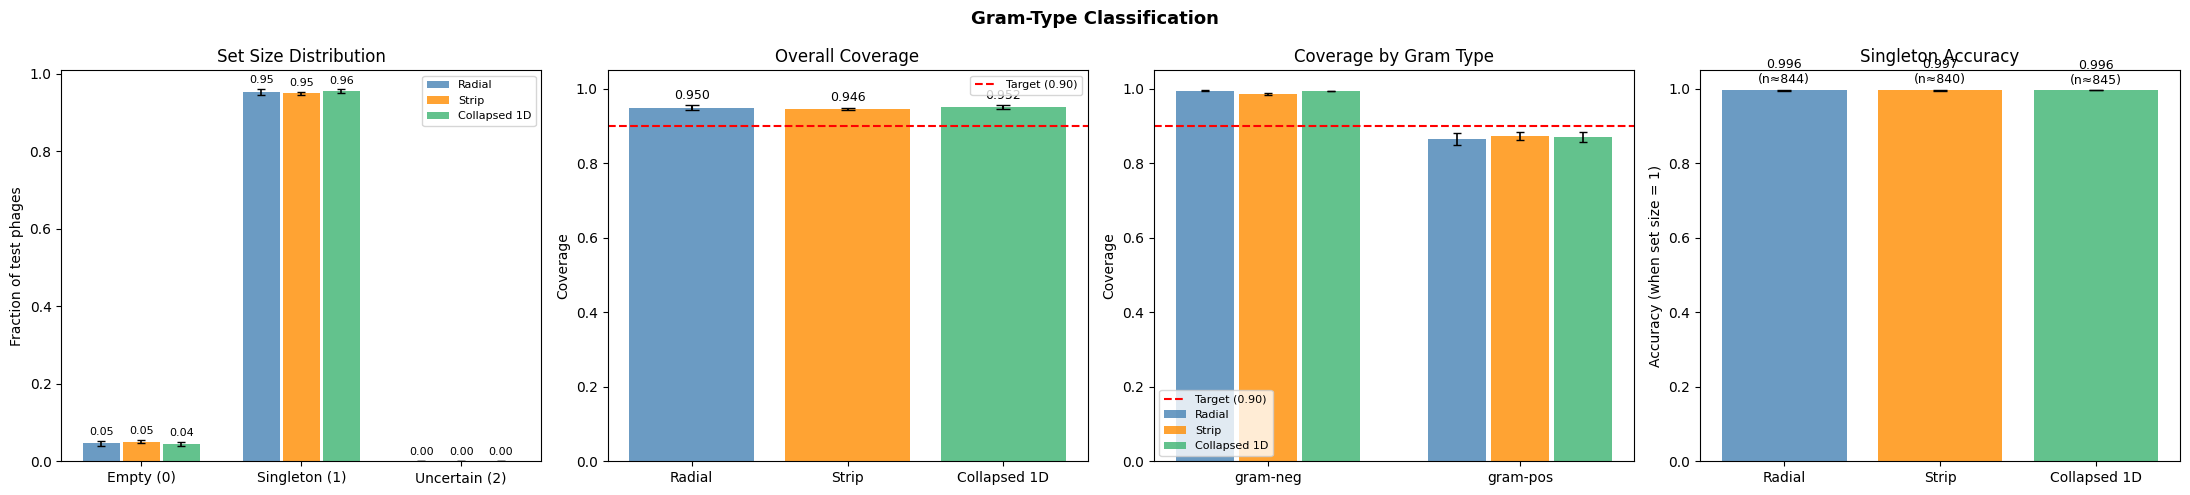

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = ["steelblue", "darkorange", "mediumseagreen"]

def _mean_std(key, field):
    vals = np.array([m[field] for m in all_metrics[key]])
    return vals.mean(), vals.std()

# Plot 1: Set size distribution (fraction of phages) 
ax = axes[0]
x = np.array([0, 1, 2])
offsets = [-0.25, 0.0, 0.25]
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    means, stds = [], []
    for s in [0, 1, 2]:
        fracs = np.array([
            sum(1 for sz in m["set_sizes"] if sz == s) / len(m["set_sizes"])
            for m in all_metrics[key]
        ])
        means.append(fracs.mean())
        stds.append(fracs.std())
    bars = ax.bar(x + offset, means, width=0.23, label=name, color=c, alpha=0.8)
    ax.errorbar(x + offset, means, yerr=stds, fmt="none", color="black", capsize=3, linewidth=1.2)
    for rect in bars:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, means[list(bars).index(rect)] + stds[list(bars).index(rect)] + 0.01, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(["Empty (0)", "Singleton (1)", "Uncertain (2)"])
ax.set_title("Set Size Distribution")
ax.set_ylabel("Fraction of test phages")
ax.legend(fontsize=8)

# Plot 2: Overall coverage 
ax = axes[1]
means = [np.mean([m["coverage"] for m in all_metrics[k]]) for k in method_keys]
stds = [np.std ([m["coverage"] for m in all_metrics[k]]) for k in method_keys]
bars = ax.bar(methods_names, means, color=colors, alpha=0.8)
ax.errorbar(range(len(methods_names)), means, yerr=stds, fmt="none", color="black", capsize=5, linewidth=1.5)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.set_ylabel("Coverage")
ax.legend(fontsize=8)
for i, (bar, val, std) in enumerate(zip(bars, means, stds)):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Plot 3: Per-gram-type coverage
ax = axes[2]
gram_types = ["gram-neg", "gram-pos"]
x = np.arange(len(gram_types))
offsets = [-0.25, 0.0, 0.25]
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    means, stds = [], []
    for gt in gram_types:
        vals = np.array([m["per_type_coverage"][gt] for m in all_metrics[key]])
        means.append(vals.mean())
        stds.append(vals.std())
    ax.bar(x + offset, means, width=0.23, label=name, color=c, alpha=0.8)
    ax.errorbar(x + offset, means, yerr=stds, fmt="none", color="black", capsize=3, linewidth=1.2)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(gram_types)
ax.set_ylim(0, 1.05)
ax.set_title("Coverage by Gram Type")
ax.set_ylabel("Coverage")
ax.legend(fontsize=8)

# Plot 4: Singleton accuracy
ax = axes[3]
means, stds, ns = [], [], []
for key in method_keys:
    vals = np.array([m["singleton_accuracy"] for m in all_metrics[key] if m["singleton_accuracy"] is not None])
    means.append(vals.mean() if len(vals) else 0)
    stds.append (vals.std()  if len(vals) else 0)
    ns.append(int(np.mean([m["singleton_rate"] * len(m["set_sizes"]) for m in all_metrics[key]])))
bars = ax.bar(methods_names, means, color=colors, alpha=0.8)
ax.errorbar(range(len(methods_names)), means, yerr=stds, fmt="none", color="black", capsize=5, linewidth=1.5)
ax.set_ylim(0, 1.05)
ax.set_title("Singleton Accuracy")
ax.set_ylabel("Accuracy (when set size = 1)")
for bar, val, std, n_s in zip(bars, means, stds, ns):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.01, f"{val:.3f}\n(n≈{n_s})", ha="center", va="bottom", fontsize=9)

plt.suptitle(f"Gram-Type Classification", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Distribution of mean raw scores per phage:
  Overall: mean=0.327, std=0.362
  Min=0.017, Max=0.963

  Phages with mean score in (0.3, 0.7): 31 / 885

  gram-neg: mean=0.067, std=0.047
    Phages with score in (0.3, 0.7): 2 / 575

  gram-pos: mean=0.809, std=0.112
    Phages with score in (0.3, 0.7): 29 / 310


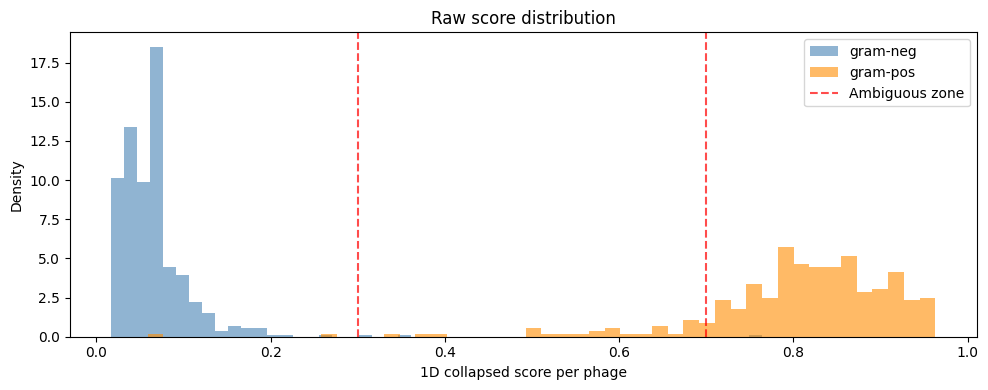

In [29]:
print("Distribution of mean raw scores per phage:")
mean_scores = test_df[valid_cols].mean(axis=1)
print(f"  Overall: mean={mean_scores.mean():.3f}, std={mean_scores.std():.3f}")
print(f"  Min={mean_scores.min():.3f}, Max={mean_scores.max():.3f}")

# How many phages have mean score near 0.5 (genuinely ambiguous)?
near_half = ((mean_scores > 0.3) & (mean_scores < 0.7)).sum()
print(f"\n  Phages with mean score in (0.3, 0.7): {near_half} / {len(mean_scores)}")

# Break down by gram type
for gt in ["gram-neg", "gram-pos"]:
    mask = test_df["host_type"] == gt
    scores = mean_scores[mask]
    print(f"\n  {gt}: mean={scores.mean():.3f}, std={scores.std():.3f}")
    print(f"    Phages with score in (0.3, 0.7): {((scores > 0.3) & (scores < 0.7)).sum()} / {len(scores)}")

plt.figure(figsize=(10, 4))
for gt, col in [("gram-neg", "steelblue"), ("gram-pos", "darkorange")]:
    mask = test_df["host_type"] == gt
    plt.hist(mean_scores[mask], bins=50, alpha=0.6, color=col, label=gt, density=True)
plt.axvline(0.3, color="red", linestyle="--", alpha=0.7, label="Ambiguous zone")
plt.axvline(0.7, color="red", linestyle="--", alpha=0.7)
plt.xlabel("1D collapsed score per phage")
plt.ylabel("Density")
plt.title("Raw score distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
mean_scores = pd.Series(test_raw.mean(axis=1), index=test_df.index)
pos_mask = test_labels == "gram-pos"
pos_indices = np.where(pos_mask)[0]

typical_pos = [i for i in pos_indices if mean_scores.iloc[i] > 0.7]
ambiguous_pos = [i for i in pos_indices if mean_scores.iloc[i] <= 0.7]

for name, results in [("Radial", radial_results), ("Strip",  strip_results), ("Collapsed", collapsed_results)]:
    cov_typical = sum("gram-pos" in results[i]["prediction_set"] for i in typical_pos)
    cov_ambiguous = sum("gram-pos" in results[i]["prediction_set"] for i in ambiguous_pos)
    print(f"{name}:")
    print(f"  Typical gram-pos (n={len(typical_pos)}): coverage = {cov_typical/len(typical_pos):.3f}")
    if ambiguous_pos:
        print(f"  Ambiguous gram-pos (n={len(ambiguous_pos)}): coverage = {cov_ambiguous/len(ambiguous_pos):.3f}")

Radial:
  Typical gram-pos (n=279): coverage = 0.968
  Ambiguous gram-pos (n=31): coverage = 0.226
Strip:
  Typical gram-pos (n=279): coverage = 0.935
  Ambiguous gram-pos (n=31): coverage = 0.258
Collapsed:
  Typical gram-pos (n=279): coverage = 0.957
  Ambiguous gram-pos (n=31): coverage = 0.000


### Method-vs-Method Scatter Plots

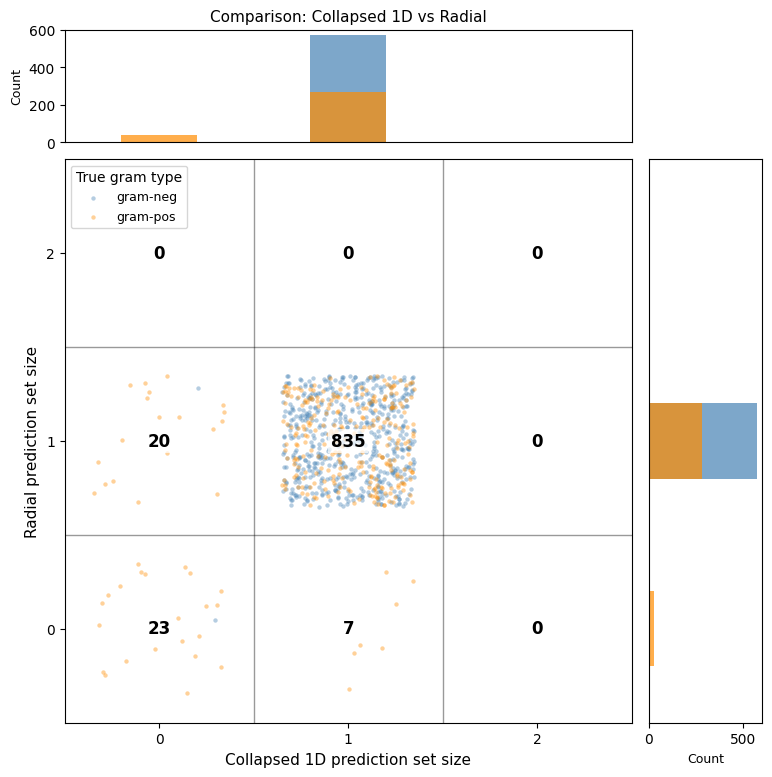

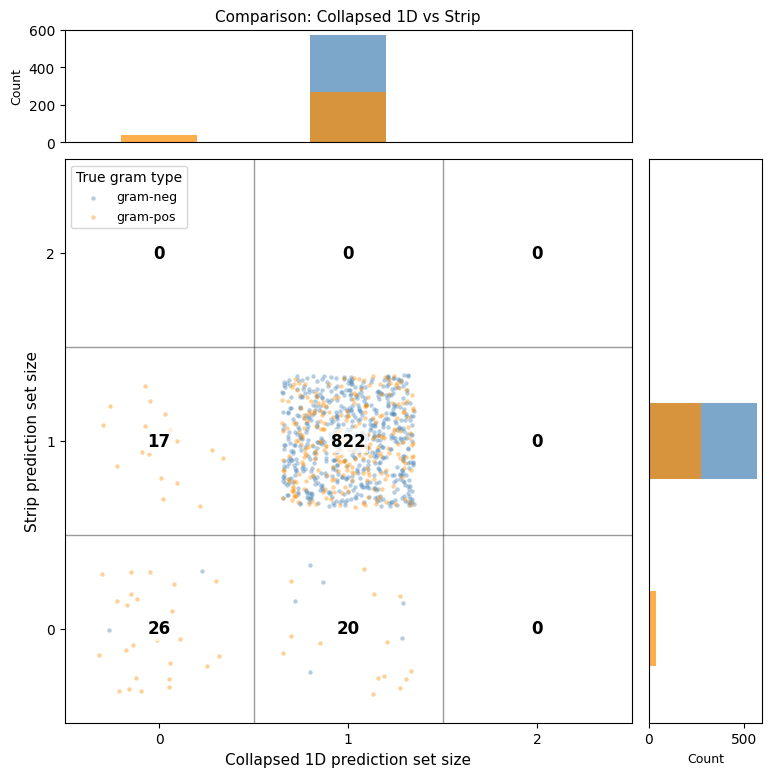

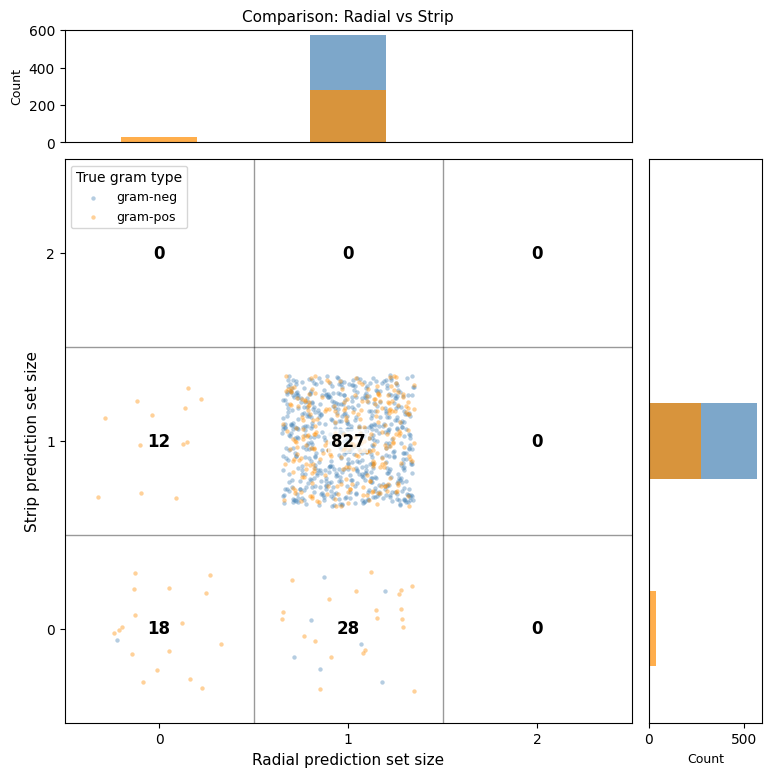

In [31]:
def plot_method_vs_method_scatter(sizes_x, sizes_y, name_x, name_y):
    gram_colors = {"gram-neg": "steelblue", "gram-pos": "darkorange"}
    fig = plt.figure(figsize=(9, 9))
    gs  = fig.add_gridspec(2, 2, width_ratios=[1, 0.2], height_ratios=[0.2, 1], hspace=0.05, wspace=0.05)
    ax_main = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[1, 1])

    jitter = 0.35
    x_jit = sizes_x + np.random.uniform(-jitter, jitter, len(sizes_x))
    y_jit = sizes_y + np.random.uniform(-jitter, jitter, len(sizes_y))

    for lbl, col in gram_colors.items():
        mask = np.array(test_labels) == lbl
        ax_main.scatter(x_jit[mask], y_jit[mask], c=col, s=10, alpha=0.4, linewidths=0, label=lbl)

    for v in [0.5, 1.5]:
        ax_main.axvline(v, color="black", linewidth=1.0, alpha=0.4)
        ax_main.axhline(v, color="black", linewidth=1.0, alpha=0.4)

    for xi in [0, 1, 2]:
        for yi in [0, 1, 2]:
            n_box = ((sizes_x == xi) & (sizes_y == yi)).sum()
            ax_main.text(xi, yi, str(n_box), ha="center", va="center", fontsize=12, fontweight="bold",
                         bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))

    ax_main.set_xticks([0, 1, 2])
    ax_main.set_yticks([0, 1, 2])
    ax_main.set_xlim(-0.5, 2.5)
    ax_main.set_ylim(-0.5, 2.5)
    ax_main.set_xlabel(f"{name_x} prediction set size", fontsize=11)
    ax_main.set_ylabel(f"{name_y} prediction set size", fontsize=11)
    ax_main.legend(title="True gram type", fontsize=9, loc="upper left")

    for lbl, col in gram_colors.items():
        mask   = np.array(test_labels) == lbl
        counts = [(sizes_x[mask] == s).sum() for s in [0, 1, 2]]
        ax_top.bar([0, 1, 2], counts, color=col, alpha=0.7, width=0.4, label=lbl)
    ax_top.set_xlim(-0.5, 2.5)
    ax_top.set_xticks([])
    ax_top.set_ylabel("Count", fontsize=9)
    ax_top.set_title(f"Comparison: {name_x} vs {name_y}", fontsize=11)

    for lbl, col in gram_colors.items():
        mask   = np.array(test_labels) == lbl
        counts = [(sizes_y[mask] == s).sum() for s in [0, 1, 2]]
        ax_right.barh([0, 1, 2], counts, color=col, alpha=0.7, height=0.4, label=lbl)
    ax_right.set_ylim(-0.5, 2.5)
    ax_right.set_yticks([])
    ax_right.set_xlabel("Count", fontsize=9)

    plt.show()


sizes_radial = np.array([len(r["prediction_set"]) for r in radial_results])
sizes_strip = np.array([len(r["prediction_set"]) for r in strip_results])
sizes_collapsed = np.array([len(r["prediction_set"]) for r in collapsed_results])

plot_method_vs_method_scatter(sizes_collapsed, sizes_radial, "Collapsed 1D", "Radial")
plot_method_vs_method_scatter(sizes_collapsed, sizes_strip, "Collapsed 1D", "Strip")
plot_method_vs_method_scatter(sizes_radial, sizes_strip, "Radial", "Strip")